Liver Disease Classification- Decison Tree

In [222]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Load Dataset

In [223]:
# Load the dataset
df = pd.read_csv('/content/data.csv')
print('Shape:', df.shape)
df.head()

Shape: (583, 11)


,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [224]:
tf = df.copy()

In [225]:
# Basic info and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  579 non-null    float64
 10  Selector   583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [226]:
# Statistical summary
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


## 2. Null Value Treatment (Mean / Median / Mode)

In [227]:
# Check null counts before treatment
print('Null values before treatment:')
print(df.isnull().sum())

Null values before treatment:
Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    4
Selector     0
dtype: int64


In [228]:
# Fill numerical columns: skewed → median, normal → mean
# Fill categorical columns: mode

for col in df.columns:
    if df[col].isnull().sum() == 0:
        continue
    if df[col].dtype == 'object':
        # Categorical → fill with mode
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        skewness = df[col].skew()
        if abs(skewness) > 1:
            # Highly skewed → use median
            df[col].fillna(df[col].median(), inplace=True)
        else:
            # Approximately normal → use mean
            df[col].fillna(df[col].mean(), inplace=True)

print('Null values after treatment:')
print(df.isnull().sum())

Null values after treatment:
Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64


/tmp/ipykernel_7001/2068143834.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


## 3. Label Encoding (Categorical → Numeric)

In [229]:
tf.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [230]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

le = LabelEncoder()   # create once

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
df.head()

Categorical columns: ['Gender']


,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## 4. Outlier Detection using IQR Method

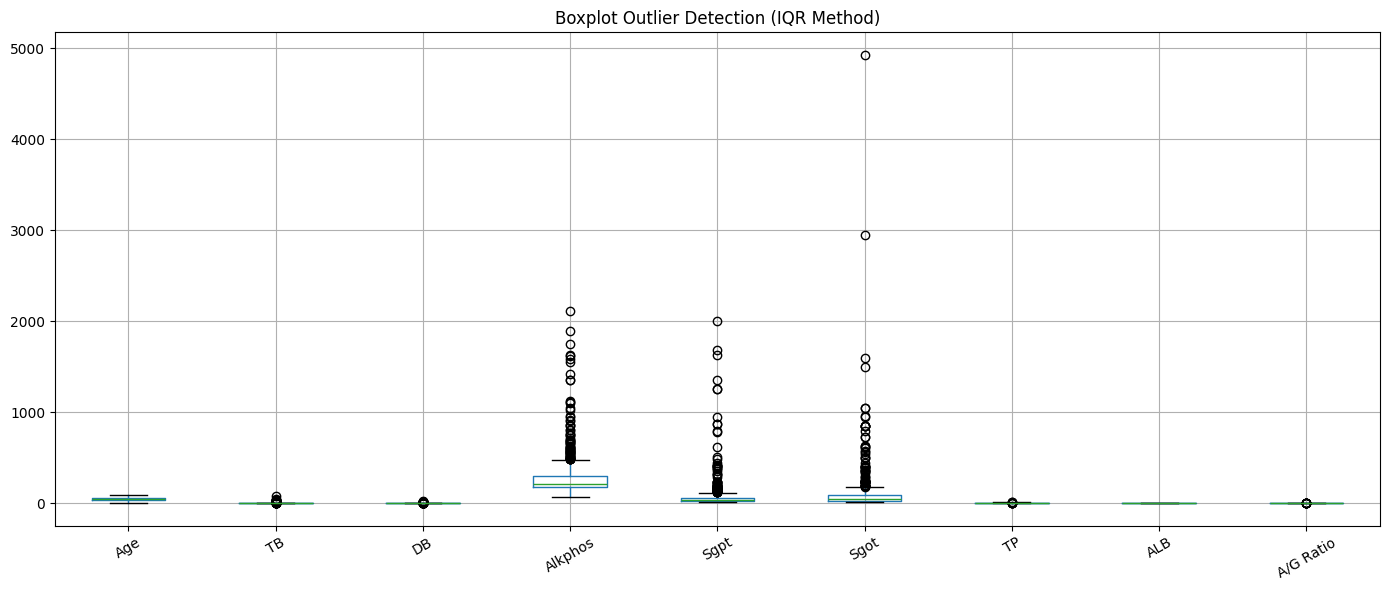

In [242]:
# Select numeric columns (excluding Gender and Selector)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['Gender', 'Selector']]

# ---- Boxplot ----
plt.figure(figsize=(14, 6))
df[num_cols].boxplot(rot=30)
plt.title('Boxplot Outlier Detection (IQR Method)')
plt.tight_layout()
plt.show()

## 5. Visualizations

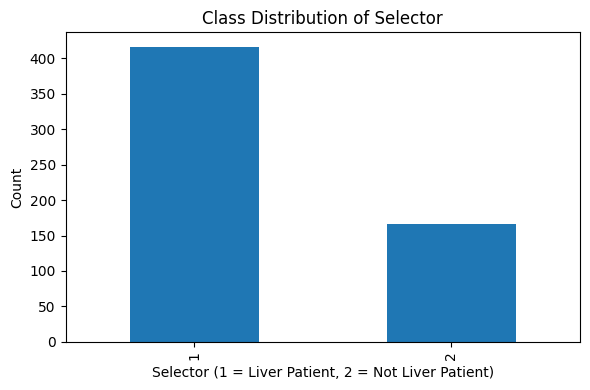

In [243]:
# --- Visualization 1: Target class distribution (Countplot) ---
plt.figure(figsize=(6, 4))
df['Selector'].value_counts().sort_index().plot(kind='bar')

plt.title('Class Distribution of Selector')
plt.xlabel('Selector (1 = Liver Patient, 2 = Not Liver Patient)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 6. Model Training - Decision Tree

In [244]:
# Define features (X) and target (y)
# Define features (X) and target (y)
X = df.drop(columns=['Selector'])
y = df['Selector']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (466, 10)
Test size : (117, 10)


In [245]:
# Decision Tree model
model = DecisionTreeClassifier(criterion='entropy',
    max_depth=7,
    min_samples_split=8,
    min_samples_leaf=4,
    random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=7, min_samples_leaf=4,
                       min_samples_split=8, random_state=42)

## 7. Model Evaluation

In [246]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')



Accuracy: 0.6838


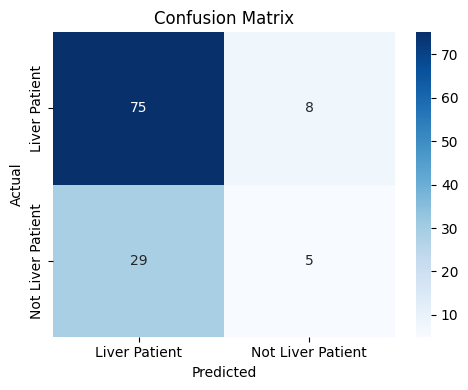

In [247]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Liver Patient', 'Not Liver Patient'],
            yticklabels=['Liver Patient', 'Not Liver Patient'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()